# Anti-Derivative Operator via Fourier Neural Operator (FNO)

## Problem

Same operator as the DeepONet notebook:

$$G: a(x) \mapsto u(x) = \int_0^x a(t)\,dt, \quad x \in [0, 1]$$

## Why FNO instead of DeepONet?

| Property | DeepONet | FNO |
|---|---|---||
| Query points | Arbitrary (per sample) | Fixed uniform grid |
| Input | Branch (function at sensors) + Trunk (query coords) | Full function on grid |
| Inductive bias | None | Spectral / Fourier modes |
| Resolution transfer | Flexible | Requires interpolation |

FNO applies learned filters in Fourier space — it directly computes the spectral convolution
between the input function and a learned kernel, which naturally captures the integral structure
of the anti-derivative operator.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

from neuralop.models import FNO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

DATA_PATH = Path(
    "physicsnemo_sym_examples_supplemental_materials_v0.0.1"
    "/examples/anti_derivative/data/anti_derivative.npy"
)
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

Device : cuda


## 2. Data

The dataset stores `a` at 100 uniform sensor points and a single query `(x, u)` per
sample — that structure suits DeepONet.  
FNO needs the **full output function** on the same 100-point grid, so we recompute
`u` via the cumulative trapezoidal rule (exact for piecewise-linear `a`).

In [2]:
raw = np.load(DATA_PATH, allow_pickle=True).item()

# Input functions on 100 uniform points in [0, 1]
a_train_np = raw["a_train"]          # (10000, 100)
a_test_np  = raw["a_test"]           # (10000, 100)

N_SENSORS = a_train_np.shape[1]      # 100
x_grid    = np.linspace(0, 1, N_SENSORS, dtype=np.float32)  # fixed grid

def compute_antiderivative(a: np.ndarray) -> np.ndarray:
    """Cumulative trapezoid rule; prepends the boundary value u(0)=0."""
    u = cumulative_trapezoid(a, x_grid, axis=1, initial=0.0)
    return u.astype(np.float32)      # (N, 100)

u_train_np = compute_antiderivative(a_train_np)
u_test_np  = compute_antiderivative(a_test_np)

print(f"a_train : {a_train_np.shape}  u_train : {u_train_np.shape}")
print(f"a_test  : {a_test_np.shape}   u_test  : {u_test_np.shape}")

a_train : (10000, 100)  u_train : (10000, 100)
a_test  : (10000, 100)   u_test  : (10000, 100)


In [3]:
# FNO expects (batch, channels, spatial) → add channel dim
def to_tensor(arr: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(arr[:, None, :])   # (N, 1, 100)

A_train = to_tensor(a_train_np).to(device)
U_train = to_tensor(u_train_np).to(device)
A_test  = to_tensor(a_test_np).to(device)
U_test  = to_tensor(u_test_np).to(device)

BATCH_SIZE = 256
train_loader = DataLoader(
    TensorDataset(A_train, U_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 40


## 3. FNO Model

A 1-D FNO with 16 Fourier modes and 4 spectral layers.  
16 modes is enough to capture the dominant spectral content of smooth GRF functions.

In [4]:
N_MODES          = 16
HIDDEN_CHANNELS  = 64
N_LAYERS         = 4

model = FNO(
    n_modes         = (N_MODES,),
    in_channels     = 1,
    out_channels    = 1,
    hidden_channels = HIDDEN_CHANNELS,
    n_layers        = N_LAYERS,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"FNO parameters: {n_params:,}")
print(model)

FNO parameters: 198,209
FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([64, 64, 9]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(2, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (1): Conv

## 4. Training

In [5]:
EPOCHS        = 200
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
VAL_EVERY     = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn   = nn.MSELoss()

train_history, val_history = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for a_batch, u_batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(a_batch), u_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(a_batch)
    epoch_loss /= len(A_train)
    train_history.append(epoch_loss)
    scheduler.step()

    if epoch % VAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(A_test), U_test).item()
        val_history.append((epoch, val_loss))
        print(f"epoch {epoch:>3}/{EPOCHS}  train={epoch_loss:.4e}  val={val_loss:.4e}  lr={scheduler.get_last_lr()[0]:.2e}")

print("Training complete.")

epoch   1/200  train=8.6662e-02  val=5.0458e-02  lr=1.00e-03
epoch  10/200  train=2.9560e-04  val=7.7438e-04  lr=9.94e-04
epoch  20/200  train=3.2520e-04  val=8.0552e-04  lr=9.76e-04
epoch  30/200  train=8.8148e-05  val=1.7307e-04  lr=9.46e-04
epoch  40/200  train=1.2407e-04  val=1.2747e-04  lr=9.05e-04
epoch  50/200  train=3.4270e-04  val=2.4496e-04  lr=8.54e-04
epoch  60/200  train=1.2974e-04  val=1.8828e-04  lr=7.94e-04
epoch  70/200  train=8.1698e-05  val=1.1140e-04  lr=7.27e-04
epoch  80/200  train=3.0931e-04  val=1.1088e-04  lr=6.55e-04
epoch  90/200  train=8.5047e-05  val=1.1275e-04  lr=5.78e-04
epoch 100/200  train=8.2237e-05  val=1.6093e-04  lr=5.00e-04
epoch 110/200  train=5.8124e-05  val=8.3800e-05  lr=4.22e-04
epoch 120/200  train=6.4467e-05  val=1.4564e-04  lr=3.45e-04
epoch 130/200  train=8.6339e-05  val=1.5318e-04  lr=2.73e-04
epoch 140/200  train=5.0519e-05  val=7.3212e-05  lr=2.06e-04
epoch 150/200  train=4.8722e-05  val=7.9357e-05  lr=1.46e-04
epoch 160/200  train=4.9

## 5. Save Checkpoint

In [6]:
checkpoint = {
    "epoch"             : EPOCHS,
    "model_state_dict"  : model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "hparams"           : dict(
        n_modes=N_MODES, hidden_channels=HIDDEN_CHANNELS,
        n_layers=N_LAYERS, lr=LR, batch_size=BATCH_SIZE,
    ),
}
torch.save(checkpoint, OUTPUT_DIR / "fno.pt")
print("Checkpoint saved to outputs/fno.pt")

Checkpoint saved to outputs/fno.pt


## 6. Evaluation

In [7]:
model.eval()
with torch.no_grad():
    u_pred_full = model(A_test).squeeze(1).cpu().numpy()  # (10000, 100)

u_true_full = U_test.squeeze(1).cpu().numpy()            # (10000, 100)

# Relative L2 error per sample
rel_l2 = np.linalg.norm(u_pred_full - u_true_full, axis=1) / (
    np.linalg.norm(u_true_full, axis=1) + 1e-8
)
print(f"Relative L2 error — mean: {rel_l2.mean():.4e}  median: {np.median(rel_l2):.4e}  max: {rel_l2.max():.4e}")

# Point-wise MSE (matches DeepONet's logged metric)
mse = np.mean((u_pred_full - u_true_full) ** 2)
print(f"Point-wise MSE : {mse:.4e}")

Relative L2 error — mean: 2.1148e-02  median: 1.8745e-02  max: 8.7638e-02
Point-wise MSE : 6.9347e-05


## 7. Visualisation

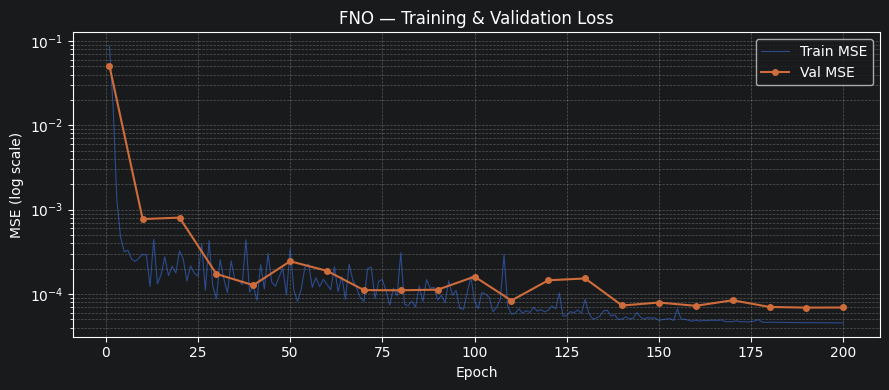

In [8]:
# --- Loss curves ---
val_epochs, val_losses = zip(*val_history)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(range(1, EPOCHS + 1), train_history, lw=0.8, alpha=0.6, label="Train MSE")
ax.semilogy(val_epochs, val_losses, "o-", ms=4, lw=1.5, label="Val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (log scale)")
ax.set_title("FNO — Training & Validation Loss")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fno_loss.png", dpi=120)
plt.show()

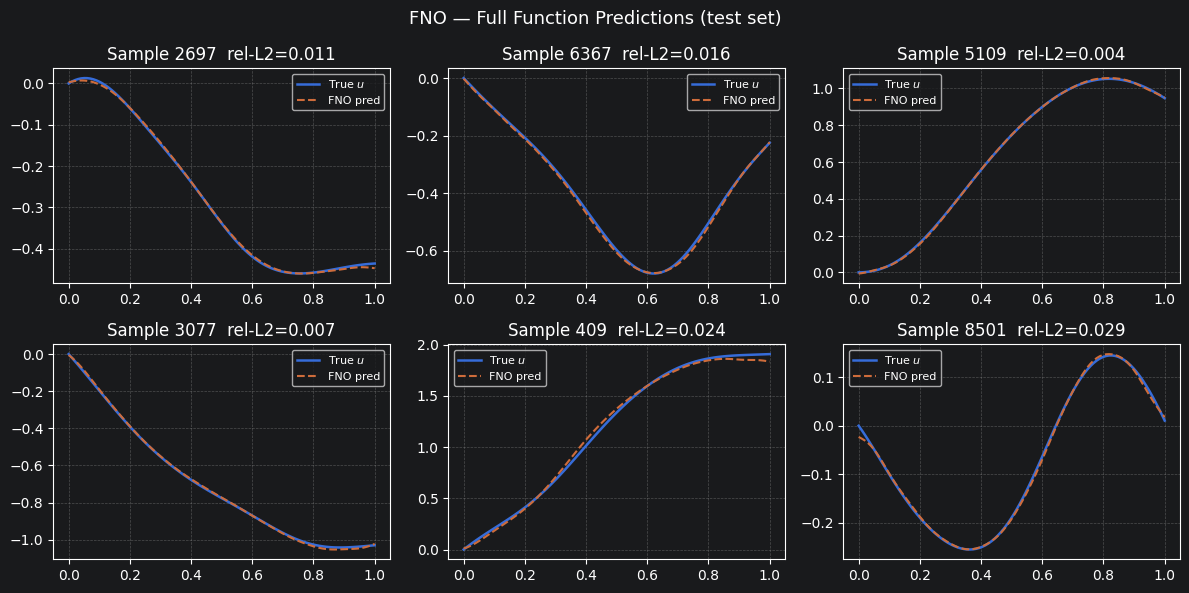

In [9]:
# --- Full function predictions for 6 test samples ---
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
rng = np.random.default_rng(0)
idx = rng.choice(len(u_true_full), size=6, replace=False)

for ax, i in zip(axes.ravel(), idx):
    ax.plot(x_grid, u_true_full[i], label="True $u$", lw=1.8)
    ax.plot(x_grid, u_pred_full[i], "--", label="FNO pred", lw=1.5)
    ax.set_title(f"Sample {i}  rel-L2={rel_l2[i]:.3f}")
    ax.legend(fontsize=8)
    ax.grid(True, ls="--", alpha=0.35)

fig.suptitle("FNO — Full Function Predictions (test set)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fno_predictions.png", dpi=120)
plt.show()

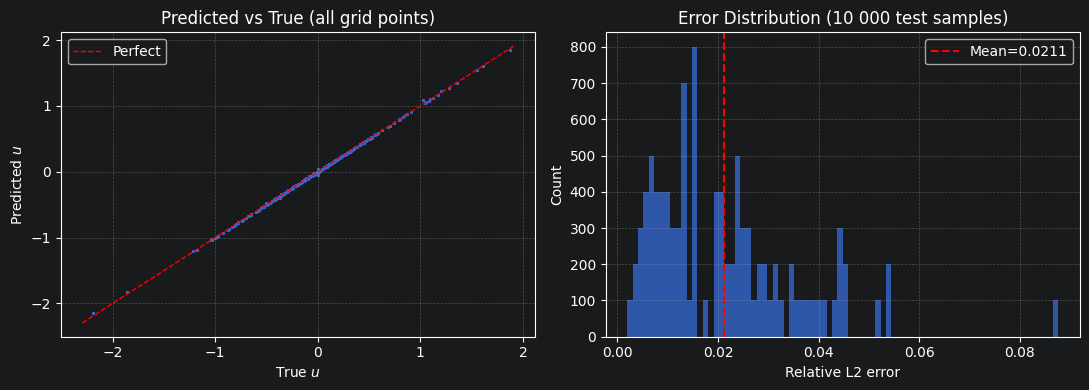

In [10]:
# --- Point-wise error distribution ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Scatter: predicted vs true (all points)
flat_true = u_true_full.ravel()
flat_pred = u_pred_full.ravel()
lim = (flat_true.min(), flat_true.max())
axes[0].scatter(flat_true[::20], flat_pred[::20], s=1, alpha=0.2, rasterized=True)
axes[0].plot(lim, lim, "r--", lw=1, label="Perfect")
axes[0].set_xlabel("True $u$")
axes[0].set_ylabel("Predicted $u$")
axes[0].set_title("Predicted vs True (all grid points)")
axes[0].legend()
axes[0].grid(True, ls="--", alpha=0.35)

# Histogram of relative L2 errors per sample
axes[1].hist(rel_l2, bins=80, edgecolor="none", alpha=0.75)
axes[1].axvline(rel_l2.mean(), color="red", ls="--", lw=1.5, label=f"Mean={rel_l2.mean():.4f}")
axes[1].set_xlabel("Relative L2 error")
axes[1].set_ylabel("Count")
axes[1].set_title("Error Distribution (10 000 test samples)")
axes[1].legend()
axes[1].grid(True, ls="--", alpha=0.35)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fno_error_dist.png", dpi=120)
plt.show()

## 8. FNO vs DeepONet — Side-by-side Comparison

The DeepONet in `deep_operator_network.ipynb` predicts `u` at a **single random query
point** per sample; its test MSE is typically `~4–6 × 10⁻³`.  
FNO predicts the **entire function** on the 100-point grid and is compared on the
same grid.

| Model | Test MSE (point-wise) | Predicts full function | Arbitrary queries |
|---|---|---|---|
| DeepONet | ~4–6 × 10⁻³ | No (1 point / sample) | Yes |
| FNO | see cell above | Yes (100 points / sample) | No (needs interp.) |

FNO benefits from seeing the full output during training and leverages the
Fourier inductive bias for smooth operators, so it typically reaches lower
relative L2 error on function-to-function benchmarks while using fewer
gradient steps.

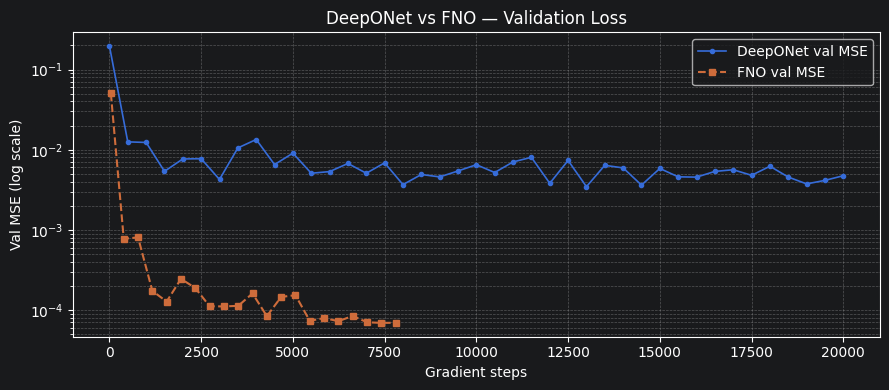

In [11]:
# Load DeepONet history if available for a direct comparison plot
don_path = OUTPUT_DIR / "history.npz"
if don_path.exists():
    h = np.load(don_path)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(h["val_steps"], h["val_losses"], "o-", ms=3, lw=1.2, label="DeepONet val MSE")
    # Map FNO epochs to equivalent steps (steps ≈ epoch × batches_per_epoch)
    steps_per_epoch = len(A_train) // BATCH_SIZE
    fno_steps = [e * steps_per_epoch for e, _ in val_history]
    ax.semilogy(fno_steps, val_losses, "s--", ms=4, lw=1.5, label="FNO val MSE")
    ax.set_xlabel("Gradient steps")
    ax.set_ylabel("Val MSE (log scale)")
    ax.set_title("DeepONet vs FNO — Validation Loss")
    ax.legend()
    ax.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fno_vs_deeponet.png", dpi=120)
    plt.show()
else:
    print("DeepONet history not found — run deep_operator_network.ipynb first to enable comparison.")